In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('train.csv')

# Sanity checks
print(df.shape)
print(df.dtypes)
df.head()

(80000, 41)
runner_id                          object
age                                 int64
gender                             object
running_experience_months           int64
previous_marathon_count             int64
training_program                   object
motivation_level                    int64
personal_best_minutes             float64
weekly_mileage_km                 float64
weekly_mileage_miles              float64
runs_per_week                       int64
long_run_distance_km              float64
speed_work_sessions_per_week        int64
rest_days_per_week                  int64
training_adherence_pct              int64
consecutive_weeks_no_miss           int64
cross_training_hours_per_week     float64
resting_heart_rate_bpm              int64
vo2_max                           float64
bmi                               float64
recovery_score                    float64
sleep_hours_avg                   float64
injury_count                        int64
injury_severity       

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [3]:
pd.read_csv('train.csv').columns.tolist()

['runner_id',
 'age',
 'gender',
 'running_experience_months',
 'previous_marathon_count',
 'training_program',
 'motivation_level',
 'personal_best_minutes',
 'weekly_mileage_km',
 'weekly_mileage_miles',
 'runs_per_week',
 'long_run_distance_km',
 'speed_work_sessions_per_week',
 'rest_days_per_week',
 'training_adherence_pct',
 'consecutive_weeks_no_miss',
 'cross_training_hours_per_week',
 'resting_heart_rate_bpm',
 'vo2_max',
 'bmi',
 'recovery_score',
 'sleep_hours_avg',
 'injury_count',
 'injury_severity',
 'nutrition_score',
 'hydration_consistency',
 'training_streak_days',
 'missed_workout_pct',
 'early_morning_run_frequency',
 'weather_condition_training_pct',
 'goal_completion_rate',
 'run_club_attendance_rate',
 'warmup_adherence_pct',
 'stretching_adherence_pct',
 'marathon_date',
 'marathon_weather',
 'course_difficulty',
 'target_finish_time_minutes',
 'actual_finish_time_minutes',
 'mental_preparation_score',
 'medal_outcome']

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

runner_id                             0
age                                   0
gender                                0
running_experience_months             0
previous_marathon_count               0
training_program                      0
motivation_level                      0
personal_best_minutes             10745
weekly_mileage_km                     0
weekly_mileage_miles                  0
runs_per_week                         0
long_run_distance_km                  0
speed_work_sessions_per_week          0
rest_days_per_week                    0
training_adherence_pct                0
consecutive_weeks_no_miss             0
cross_training_hours_per_week      7983
resting_heart_rate_bpm                0
vo2_max                            9611
bmi                                   0
recovery_score                        0
sleep_hours_avg                    3942
injury_count                          0
injury_severity                   47350
nutrition_score                    6402


<Axes: xlabel='actual_finish_time_minutes', ylabel='Count'>

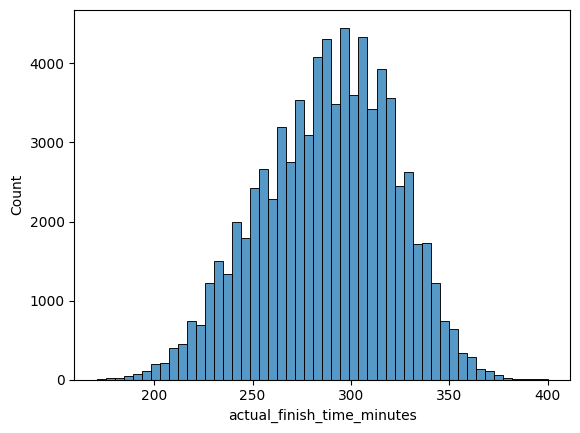

In [5]:
# Target distribution
sns.histplot(df['actual_finish_time_minutes'], bins=50)

In [6]:
df[['target_finish_time_minutes', 'actual_finish_time_minutes']].describe()


,target_finish_time_minutes,actual_finish_time_minutes
count,80000.000000,78011.000000
mean,249.308687,287.931407
std,30.372115,33.648005
min,150.000000,171.000000
25%,228.000000,265.000000
50%,252.000000,290.000000
75%,272.000000,313.000000
max,350.000000,400.000000


In [7]:
# Categorical features
df.select_dtypes(include='object').columns.tolist()

['runner_id',
 'gender',
 'training_program',
 'injury_severity',
 'marathon_date',
 'marathon_weather',
 'course_difficulty']

In [8]:
# 1. Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map = {"Minor": 1, "Moderate": 2, "Severe": 3}

df['training_program'] = df['training_program'].map(training_map)
df['course_difficulty'] = df['course_difficulty'].map(course_map)
df['injury_severity'] = df['injury_severity'].map(injury_map).fillna(0)

# 2. Nominal — one-hot on full df
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df[['gender', 'marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                      columns=ohe.get_feature_names_out(['gender', 'marathon_weather']),
                      index=df.index)

df = df.drop(columns=['gender', 'marathon_weather'])
df = pd.concat([df, ohe_df], axis=1)

# 4. Confirm
print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())

(80000, 46)
['runner_id', 'marathon_date']


## Model V1

In [ ]:
minimum_drop_list = [
   "runner_id",
    "weekly_mileage_miles",
    "target_finish_time_minutes",
    "medal_outcome",
    "marathon_date",
    "personal_best_minutes"
]

df_v1 = df.drop(columns=[c for c in minimum_drop_list if c in df.columns])
print(df.shape)

(80000, 46)


In [10]:
print(df_v1.select_dtypes(include='object').columns.tolist())

[]


In [25]:
corr_target = df_v1.corr(numeric_only=True)['actual_finish_time_minutes'].sort_values()
print(corr_target)

training_program                 -0.748738
running_experience_months        -0.649845
speed_work_sessions_per_week     -0.350391
runs_per_week                    -0.311368
vo2_max                          -0.224152
long_run_distance_km             -0.138232
weekly_mileage_km                -0.112104
cross_training_hours_per_week    -0.096615
marathon_weather_Sunny           -0.054512
recovery_score                   -0.049599
motivation_level                 -0.048943
run_club_attendance_rate         -0.046154
goal_completion_rate             -0.039659
consecutive_weeks_no_miss        -0.039239
early_morning_run_frequency      -0.035269
weather_condition_training_pct   -0.030363
nutrition_score                  -0.028336
warmup_adherence_pct             -0.023864
training_streak_days             -0.021734
mental_preparation_score         -0.016830
sleep_hours_avg                  -0.014660
stretching_adherence_pct         -0.011571
training_adherence_pct           -0.006953
gender_Male

In [12]:
df_v1.head()

,age,running_experience_months,previous_marathon_count,training_program,motivation_level,weekly_mileage_km,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,rest_days_per_week,...,course_difficulty,actual_finish_time_minutes,mental_preparation_score,gender_Male,gender_Non-binary,marathon_weather_Cold,marathon_weather_Hot,marathon_weather_Rainy,marathon_weather_Sunny,marathon_weather_Windy
0,25,48,0,2,4,20.0,5,15.0,1,2,...,2,297.0,5,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,43,151,2,3,1,20.0,5,15.0,2,2,...,2,231.0,7,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,32,82,3,3,6,23.1,6,15.0,2,1,...,1,234.0,9,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,57,6,0,1,8,27.3,5,15.0,0,2,...,3,276.0,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,54,11,0,1,3,20.0,5,15.0,0,2,...,2,296.0,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0


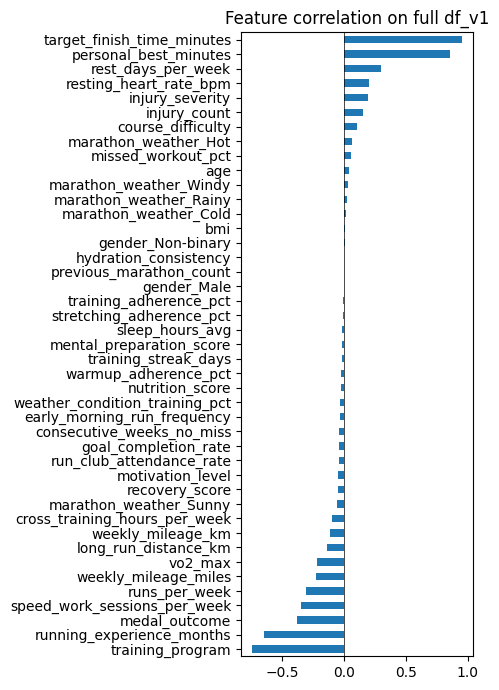

In [20]:
corr_target.drop('actual_finish_time_minutes').plot(kind='barh', figsize=(5, 7))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Feature correlation on full df_v1')
plt.tight_layout()

In [32]:
# Dropping DNFs => different problem
df_v1 = df_v1[df_v1['actual_finish_time_minutes'].notna()].copy()

In [33]:
df_v1.isnull().sum()[df.isnull().sum() > 0]

cross_training_hours_per_week    7783
vo2_max                          9362
sleep_hours_avg                  3840
nutrition_score                  6255
hydration_consistency            6271
actual_finish_time_minutes          0
dtype: int64

In [34]:
X_v1 = df_v1.drop(columns=['actual_finish_time_minutes'])
y_v1 = df_v1['actual_finish_time_minutes']

In [35]:
# Impute Median on remaining missing values
X_v1 = X_v1.fillna(X_v1.median(numeric_only=True))

In [36]:
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(X_v1, y_v1, test_size=0.2, random_state=42)

In [37]:
# Train the model
model_v1 = LinearRegression()
model_v1.fit(X_train_v1, y_train_v1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
# Evaluate the model
y_pred_v1 = model_v1.predict(X_test_v1)

/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [39]:
print(f"Baseline R2 Score: {r2_score(y_test_v1, y_pred_v1):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test_v1, y_pred_v1):.2f} minutes")

Baseline R2 Score: 0.6350
Baseline MAE: 16.12 minutes


## Model V2 - extended feature drop list

In [ ]:
extended_drop_list = [
    # Minimum drops
    "runner_id",
    "weekly_mileage_miles",
    "target_finish_time_minutes",
    "medal_outcome",
    "marathon_date",
    "personal_best_minutes",

    # Gender — dropping after OHE to keep preprocessing constant
    "gender_Male",
    "gender_Non-binary",

    # Near-zero correlation
    "previous_marathon_count",
    "hydration_consistency",
    "bmi",

    # Redundant
    "training_streak_days",
    "missed_workout_pct",

    # Race day factors
    "marathon_weather_Cold",
    "marathon_weather_Rainy",
    "marathon_weather_Windy",
    "marathon_weather_Hot",
    "marathon_weather_Sunny",
    "course_difficulty",
]

df_v2 = df.drop(columns=[c for c in extended_drop_list if c in df.columns])
print(df_v2.shape)

(80000, 27)


In [41]:
# DNF filter
df_v2 = df_v2[df_v2['actual_finish_time_minutes'].notna()].copy()

# Split X and y
X_v2 = df_v2.drop(columns=['actual_finish_time_minutes'])
y_v2 = df_v2['actual_finish_time_minutes']

# Impute
X_v2 = X_v2.fillna(X_v2.median(numeric_only=True))

# Train test split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# Train model
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred_v2 = model_v2.predict(X_test_v2)

/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/cfk/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [43]:
print(f"Baseline R2 Score: {r2_score(y_test_v2, y_pred_v2):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test_v2, y_pred_v2):.2f} minutes")

Baseline R2 Score: 0.6159
Baseline MAE: 16.57 minutes


## Model V3 - XBoost on V1 drop list

In [46]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.2 MB/s  0:00:00


In [51]:
from xgboost import XGBRegressor

model_xgb_v1 = XGBRegressor(random_state=42)

scores_mae = cross_val_score(model_xgb_v1, X_train_v1, y_train_v1,
                             cv=5,
                             scoring='neg_mean_absolute_error')

scores_r2 = cross_val_score(model_xgb_v1, X_train_v1, y_train_v1,
                            cv=5,
                            scoring='r2')

print(f"XGBoost MAE: {-scores_mae.mean():.1f} minutes")
print(f"XGBoost R2: {scores_r2.mean():.3f}")

XGBoost MAE: 16.5 minutes
XGBoost R2: 0.624


In [50]:
# Check baseline v1 scores for comparison
print(f"LinReg MAE: 16.12 minutes")
print(f"LinReg R2: 0.6350")
print(f"XGBoost MAE: 16.5 minutes")
print(f"XGBoost R2: 0.624")

LinReg MAE: 16.12 minutes
LinReg R2: 0.6350
XGBoost MAE: 16.5 minutes
XGBoost R2: 0.624
